In [9]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv("data/processed/bitcoin_processed.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df.set_index("timestamp", inplace=True)

data = df["close"]

In [11]:
train = data[:int(len(data)*0.8)]
test = data[int(len(data)*0.8):]

In [12]:
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

c:\Users\racha\anaconda3\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\racha\anaconda3\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\racha\anaconda3\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [13]:
forecast = model_fit.forecast(steps=len(test))

In [14]:
import pandas as pd

arima_pred = pd.DataFrame(forecast)

arima_pred.columns = ["prediction"]

In [15]:
import os

os.makedirs("../results", exist_ok=True)

arima_pred.to_csv("../results/arima_predictions.csv", index=False)

print("ARIMA predictions saved successfully")

ARIMA predictions saved successfully


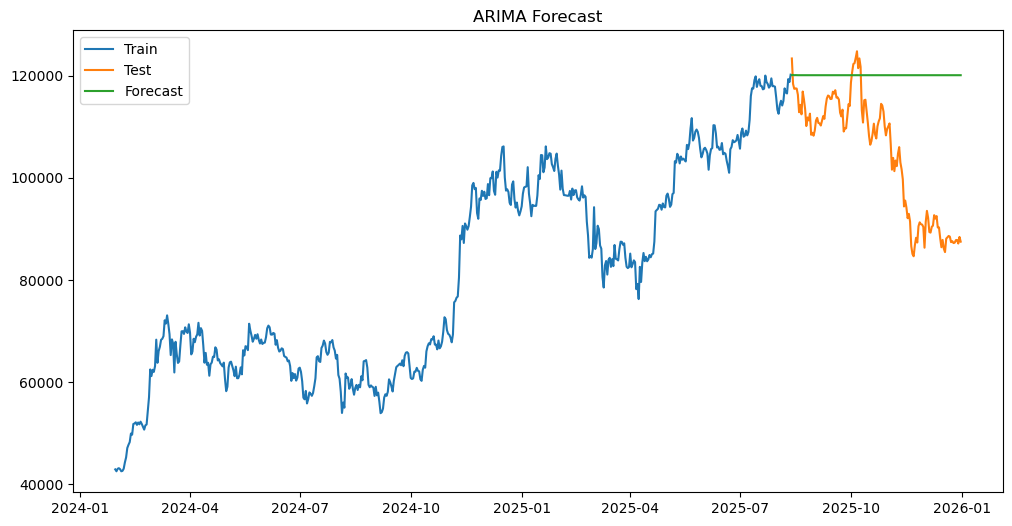

In [16]:
plt.figure(figsize=(12,6))

plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast, label="Forecast")

plt.legend()
plt.title("ARIMA Forecast")
plt.show()